# Speculative Speculative Decoding — Demo

This notebook compares three generation strategies on a single GPU:
- **AR**: Standard autoregressive generation (one token per model call).
- **SD**: Speculative Decoding (draft K tokens with GPT-2, verify with GPT-2-XL).
- **SSD**: Speculative Speculative Decoding (SD + Saguaro cache pre-computation).


In [1]:
import sys
import os

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import torch
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.3 GB


## Load Models

Draft: `gpt2` (117M parameters)  
Target: `gpt2-xl` (1.5B parameters)  
Both loaded in `float16` to fit on the RTX 3050 4GB.

In [2]:
from src.utils import load_models

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DRAFT_NAME = "gpt2"
TARGET_NAME = "gpt2-xl"

print(f"Loading models on {DEVICE} ...")
draft_model, target_model, tokenizer = load_models(DRAFT_NAME, TARGET_NAME, DEVICE)
print("Models loaded.")

if torch.cuda.is_available():
    used = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM used: {used:.2f} / {total:.1f} GB")

Loading models on cuda ...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

Models loaded.
VRAM used: 3.44 / 4.3 GB


## Prompt and Configurations

In [3]:
from src.speculative import SpeculativeConfig
from src.ssd import SSDConfig

PROMPT = (
    "The history of artificial intelligence began in antiquity, with myths, "
    "stories and rumors of artificial beings endowed with intelligence. The "
    "seeds of modern AI were planted by classical philosophers who attempted "
    "to describe the process of human thinking as the mechanical manipulation of symbols."
)

MAX_NEW_TOKENS = 128
TEMPERATURE = 0.8
K = 4

sd_config = SpeculativeConfig(K=K, temperature=TEMPERATURE, device=DEVICE)
ssd_config = SSDConfig(
    K=K,
    temperature=TEMPERATURE,
    device=DEVICE,
    cache_budget_B=20,
    saguaro_C=0.5,
    acceptance_rate_estimate=0.7,
    power_law_r=0.5,
    fallback="neural",
)

print("Prompt (first 100 chars):", PROMPT[:100])
print(f"max_new_tokens={MAX_NEW_TOKENS}, temperature={TEMPERATURE}, K={K}")

Prompt (first 100 chars): The history of artificial intelligence began in antiquity, with myths, stories and rumors of artific
max_new_tokens=128, temperature=0.8, K=4


## Run Autoregressive Generation

In [4]:
from src.autoregressive import generate_autoregressive

print("Running AR generation...")
ar_text, ar_metrics = generate_autoregressive(
    model=target_model,
    tokenizer=tokenizer,
    prompt=PROMPT,
    max_new_tokens=MAX_NEW_TOKENS,
    temperature=TEMPERATURE,
    device=DEVICE,
)
print(f"AR: {ar_metrics.total_tokens} tokens in {ar_metrics.total_time_s:.1f}s "
      f"= {ar_metrics.tokens_per_second:.1f} tok/s")
print("\nGenerated text (first 200 chars):")
print(ar_text[:200])

Running AR generation...


AR: 128 tokens in 4.5s = 28.5 tok/s

Generated text (first 200 chars):


In the second half of the 19th century, the English philosopher Alan Turing was awarded the 1928 Nobel Prize in physics for his work on the computer. Turing was most famous for his work on the Enigm


## Run Speculative Decoding

In [5]:
from src.speculative import generate_speculative

print("Running SD generation...")
sd_text, sd_metrics = generate_speculative(
    draft_model=draft_model,
    target_model=target_model,
    tokenizer=tokenizer,
    prompt=PROMPT,
    max_new_tokens=MAX_NEW_TOKENS,
    config=sd_config,
)
print(f"SD: {sd_metrics.total_tokens} tokens in {sd_metrics.total_time_s:.1f}s "
      f"= {sd_metrics.tokens_per_second:.1f} tok/s")
print(f"Mean acceptance rate: {sd_metrics.mean_acceptance_rate:.2%}")
print(f"Mean tokens/round: {sd_metrics.mean_tokens_per_round:.2f}")
print("\nGenerated text (first 200 chars):")
print(sd_text[:200])

Running SD generation...


SD: 129 tokens in 4.3s = 29.9 tok/s
Mean acceptance rate: 46.67%
Mean tokens/round: 2.87

Generated text (first 200 chars):
 Over the next two thousand years the study of thought became the foundation of the study of mathematics. As the modern scientific revolution with its revolution in mathematics began to make possible 


## Run Speculative Speculative Decoding

In [6]:
from src.ssd import generate_ssd

print("Running SSD generation...")
ssd_text, ssd_metrics = generate_ssd(
    draft_model=draft_model,
    target_model=target_model,
    tokenizer=tokenizer,
    prompt=PROMPT,
    max_new_tokens=MAX_NEW_TOKENS,
    config=ssd_config,
)
print(f"SSD: {ssd_metrics.total_tokens} tokens in {ssd_metrics.total_time_s:.1f}s "
      f"= {ssd_metrics.tokens_per_second:.1f} tok/s")
print(f"Mean acceptance rate: {ssd_metrics.mean_acceptance_rate:.2%}")
print(f"Mean tokens/round: {ssd_metrics.mean_tokens_per_round:.2f}")
print(f"Cache hit rate: {ssd_metrics.cache_hit_rate:.2%}")
print("\nGenerated text (first 200 chars):")
print(ssd_text[:200])

Running SSD generation...


SSD: 128 tokens in 44.1s = 2.9 tok/s
Mean acceptance rate: 35.38%
Mean tokens/round: 2.42
Cache hit rate: 43.40%

Generated text (first 200 chars):
 In the 17th century, philosophers such as Francis Bacon and John Locke began to develop a theory of computation, and the study of science as an attempt to define the limits of human intelligence. The


## Plot 1: Tokens per Second Comparison

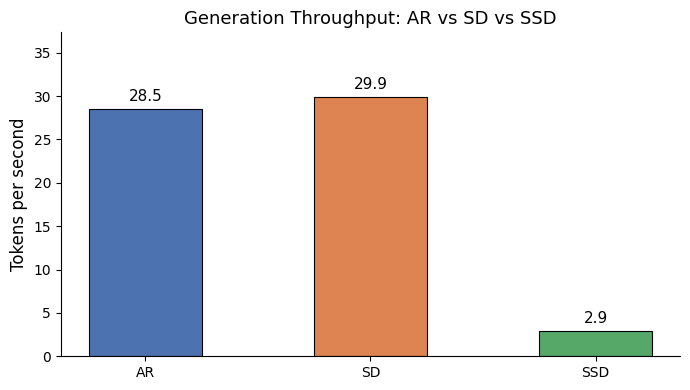

Saved tokens_per_second.png


In [7]:
os.makedirs("../results/plots", exist_ok=True)

labels = ["AR", "SD", "SSD"]
tps_values = [
    ar_metrics.tokens_per_second,
    sd_metrics.tokens_per_second,
    ssd_metrics.tokens_per_second,
]
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, tps_values, color=colors, width=0.5, edgecolor="black", linewidth=0.8)
ax.set_ylabel("Tokens per second", fontsize=12)
ax.set_title("Generation Throughput: AR vs SD vs SSD", fontsize=13)
ax.set_ylim(0, max(tps_values) * 1.25)

for bar, val in zip(bars, tps_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(tps_values) * 0.02,
        f"{val:.1f}",
        ha="center",
        va="bottom",
        fontsize=11,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../results/plots/tokens_per_second.png", dpi=150)
plt.show()
print("Saved tokens_per_second.png")

## Plot 2: SSD Cache Hit Rate Over Time (Rolling-20)

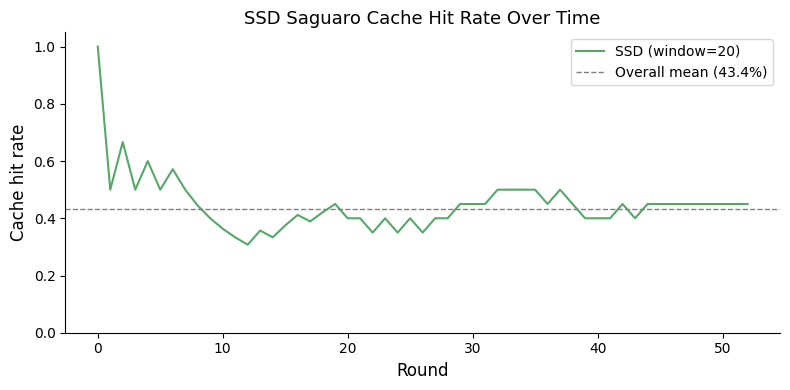

Saved cache_hit_rate.png


In [8]:
from src.metrics import MetricsAccumulator

ssd_acc = MetricsAccumulator(_results=ssd_metrics.round_results)
rolling_hits = ssd_acc.rolling_cache_hit_rate(window=20)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rolling_hits, color="#55A868", linewidth=1.5, label="SSD (window=20)")
ax.axhline(
    ssd_metrics.cache_hit_rate,
    color="gray",
    linestyle="--",
    linewidth=1,
    label=f"Overall mean ({ssd_metrics.cache_hit_rate:.1%})",
)
ax.set_xlabel("Round", fontsize=12)
ax.set_ylabel("Cache hit rate", fontsize=12)
ax.set_title("SSD Saguaro Cache Hit Rate Over Time", fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../results/plots/cache_hit_rate.png", dpi=150)
plt.show()
print("Saved cache_hit_rate.png")

## Plot 3: Tokens per Round Distribution — SD vs SSD

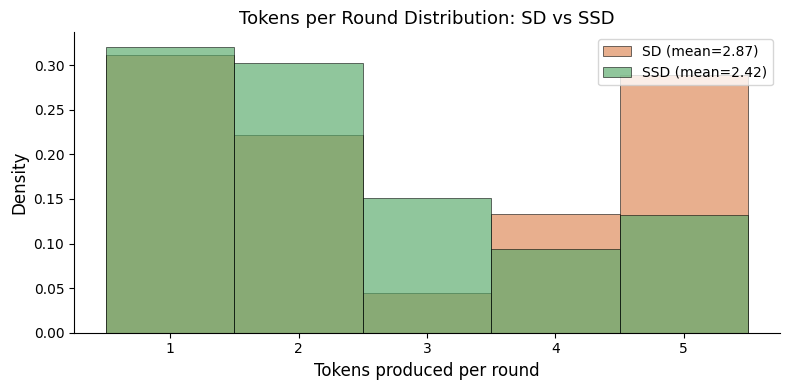

Saved tokens_per_round.png


In [9]:
sd_tpr = [len(r.all_tokens) for r in sd_metrics.round_results]
ssd_tpr = [len(r.all_tokens) for r in ssd_metrics.round_results]

bins = np.arange(0.5, K + 2.5, 1.0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    sd_tpr,
    bins=bins,
    alpha=0.65,
    color="#DD8452",
    label=f"SD (mean={np.mean(sd_tpr):.2f})",
    edgecolor="black",
    linewidth=0.6,
    density=True,
)
ax.hist(
    ssd_tpr,
    bins=bins,
    alpha=0.65,
    color="#55A868",
    label=f"SSD (mean={np.mean(ssd_tpr):.2f})",
    edgecolor="black",
    linewidth=0.6,
    density=True,
)
ax.set_xlabel("Tokens produced per round", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Tokens per Round Distribution: SD vs SSD", fontsize=13)
ax.set_xticks(range(1, K + 2))
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../results/plots/tokens_per_round.png", dpi=150)
plt.show()
print("Saved tokens_per_round.png")

## Plot 4: Rolling Acceptance Rate — SD vs SSD

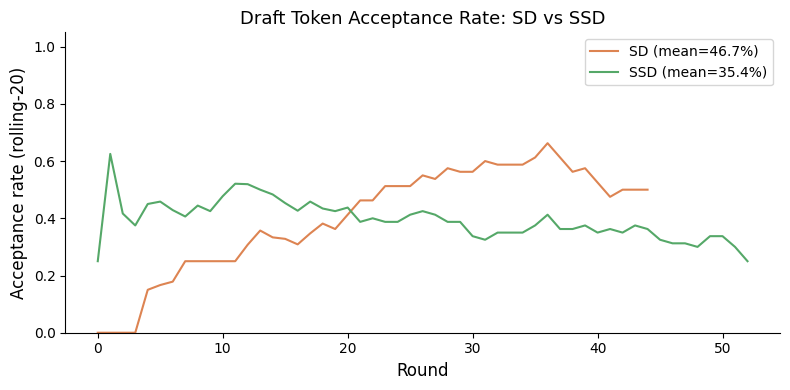

Saved acceptance_rate.png


In [10]:
sd_acc_obj = MetricsAccumulator(_results=sd_metrics.round_results)
ssd_acc_obj = MetricsAccumulator(_results=ssd_metrics.round_results)

sd_rolling_ar = sd_acc_obj.rolling_acceptance_rate(window=20, K=K)
ssd_rolling_ar = ssd_acc_obj.rolling_acceptance_rate(window=20, K=K)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sd_rolling_ar, color="#DD8452", linewidth=1.5,
        label=f"SD (mean={sd_metrics.mean_acceptance_rate:.1%})")
ax.plot(ssd_rolling_ar, color="#55A868", linewidth=1.5,
        label=f"SSD (mean={ssd_metrics.mean_acceptance_rate:.1%})")
ax.set_xlabel("Round", fontsize=12)
ax.set_ylabel("Acceptance rate (rolling-20)", fontsize=12)
ax.set_title("Draft Token Acceptance Rate: SD vs SSD", fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../results/plots/acceptance_rate.png", dpi=150)
plt.show()
print("Saved acceptance_rate.png")

## Summary Table

In [11]:
import pandas as pd

rows = [
    {
        "Method": "AR",
        "Total tokens": ar_metrics.total_tokens,
        "Total time (s)": f"{ar_metrics.total_time_s:.1f}",
        "Tokens/sec": f"{ar_metrics.tokens_per_second:.1f}",
        "Mean tokens/round": f"{ar_metrics.mean_tokens_per_round:.2f}",
        "Mean acceptance rate": "N/A",
        "Cache hit rate": "N/A",
    },
    {
        "Method": "SD",
        "Total tokens": sd_metrics.total_tokens,
        "Total time (s)": f"{sd_metrics.total_time_s:.1f}",
        "Tokens/sec": f"{sd_metrics.tokens_per_second:.1f}",
        "Mean tokens/round": f"{sd_metrics.mean_tokens_per_round:.2f}",
        "Mean acceptance rate": f"{sd_metrics.mean_acceptance_rate:.1%}",
        "Cache hit rate": "N/A",
    },
    {
        "Method": "SSD",
        "Total tokens": ssd_metrics.total_tokens,
        "Total time (s)": f"{ssd_metrics.total_time_s:.1f}",
        "Tokens/sec": f"{ssd_metrics.tokens_per_second:.1f}",
        "Mean tokens/round": f"{ssd_metrics.mean_tokens_per_round:.2f}",
        "Mean acceptance rate": f"{ssd_metrics.mean_acceptance_rate:.1%}",
        "Cache hit rate": f"{ssd_metrics.cache_hit_rate:.1%}",
    },
]

df = pd.DataFrame(rows).set_index("Method")

ar_tps = ar_metrics.tokens_per_second
sd_speedup = sd_metrics.tokens_per_second / ar_tps if ar_tps > 0 else float("nan")
ssd_speedup = ssd_metrics.tokens_per_second / ar_tps if ar_tps > 0 else float("nan")

print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(df.to_string())
print()
print(f"SD  speedup over AR: {sd_speedup:.2f}x")
print(f"SSD speedup over AR: {ssd_speedup:.2f}x")

RESULTS SUMMARY
        Total tokens Total time (s) Tokens/sec Mean tokens/round Mean acceptance rate Cache hit rate
Method                                                                                              
AR               128            4.5       28.5              1.00                  N/A            N/A
SD               129            4.3       29.9              2.87                46.7%            N/A
SSD              128           44.1        2.9              2.42                35.4%          43.4%

SD  speedup over AR: 1.05x
SSD speedup over AR: 0.10x
